In [ ]:
import numpy as np 
from RCLL import piecewise_constant_values, extract_windows_from_grid

In [ ]:
t_grid = np.linspace(times[0], times[-1], num=10000)
vals = piecewise_constant_values(times, deltaO, t_grid)
windows = extract_windows_from_grid(vals, window_size=200, stride=50)

In [ ]:
# build jump-size channel aligned with t_grid
jump_sizes = np.zeros((len(t_grid), d))
for k in range(1, len(times)):
    # find grid index equal to times[k]
    gi = np.searchsorted(t_grid, times[k])
    jump_sizes[gi] = deltaO[k] - deltaO[k-1]
# concatenate as extra features
vals_with_jumps = np.concatenate([vals, jump_sizes], axis=1)

In [6]:
import datetime
import matplotlib.pyplot as plt

In [2]:
import lakeapi

c:\Users\mxs1980\AppData\Local\miniconda3\envs\LOBEvolver\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


<Axes: xlabel='received_time'>

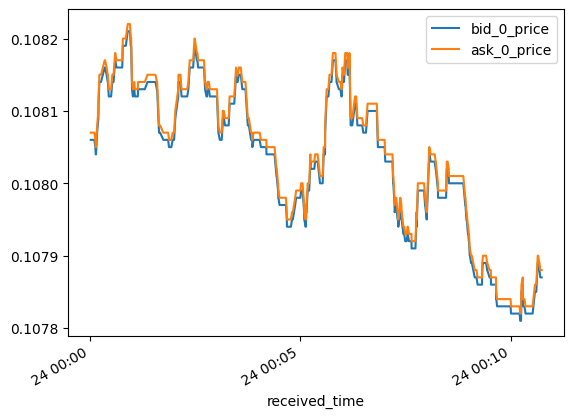

In [7]:
lakeapi.use_sample_data(anonymous_access=True)
books=lakeapi.load_data(
    table="book",
    start=datetime.datetime(2024,9,24),
    end=datetime.datetime(2024,9,25),
    symbols=["DOGE-USDT"],
    exchanges=["BINANCE"],
)
books.set_index('received_time',inplace=True)
books[['bid_0_price','ask_0_price']][:1000].plot()


In [8]:
help(lakeapi.load_data)

Help on function load_data in module lakeapi.main:

load_data(table: Literal['book', 'book_delta', 'trades', 'trades_mpid', 'candles', 'level_1', 'funding', 'open_interest', 'liquidations', 'book_1m'], start: Optional[datetime.datetime] = None, end: Optional[datetime.datetime] = None, symbols: Optional[List[str]] = None, exchanges: Optional[List[str]] = None, *, bucket: Optional[str] = None, boto3_session: Optional[boto3.session.Session] = None, use_threads: bool = True, columns: Optional[List[str]] = None, row_slice: Optional[slice] = None, drop_partition_cols: bool = False, cached: bool = True) -> pandas.core.frame.DataFrame
    Load data from Lake into Pandas DataFrame.
    
    Fetches data from a range of exchanges/symbols/dates and returns them as a Pandas DataFrame. All network access
    can be cached into a `.lake_cache` directory, which is created in the working directory.
    
    :param table: Data type to load. Eg. book (2x20 level order book snapshots ), trades, candles, 

In [9]:
books2=lakeapi.load_data(
    table='book',
)

100%|██████████| 25/25 [00:56<00:00,  2.26s/it]


In [10]:
books2.shape

(3194256, 85)

In [11]:
books2.head().shape

(5, 85)

In [12]:
books2.head()[:10]

,origin_time,received_time,sequence_number,bid_0_price,bid_0_size,bid_1_price,bid_1_size,bid_2_price,bid_2_size,bid_3_price,...,ask_16_price,ask_16_size,ask_17_price,ask_17_size,ask_18_price,ask_18_size,ask_19_price,ask_19_size,exchange,symbol
0,2022-11-01 16:29:51.295000064,2022-11-01 16:29:51.586002176,60836717815,0.015993,4992.0,0.015989,33465.0,0.015977,2299.0,0.015969,...,0.016105,4820.0,0.016111,2312.0,0.016113,15515.0,0.016115,18188.0,ASCENDEX,FTRB-USDT
1,2022-11-01 16:29:56.355000064,2022-11-01 16:29:56.676301312,60836717823,0.015994,4991.0,0.015993,4992.0,0.015989,33465.0,0.015977,...,0.016105,4820.0,0.016111,2312.0,0.016113,15515.0,0.016115,18188.0,ASCENDEX,FTRB-USDT
2,2022-11-01 16:29:57.881999872,2022-11-01 16:29:57.945887744,60836717825,0.015994,4991.0,0.015993,4992.0,0.015989,33465.0,0.015977,...,0.016105,4820.0,0.016111,2312.0,0.016113,15515.0,0.016115,18188.0,ASCENDEX,FTRB-USDT
3,2022-11-01 16:29:58.293999872,2022-11-01 16:29:58.575301120,60836717827,0.015994,4991.0,0.015993,4992.0,0.015989,33465.0,0.015977,...,0.016105,4820.0,0.016111,2312.0,0.016113,15515.0,0.016115,18188.0,ASCENDEX,FTRB-USDT
4,2022-11-01 16:30:00.538000128,2022-11-01 16:30:00.795635456,60836717829,0.015994,4991.0,0.015993,4992.0,0.015989,33465.0,0.015977,...,0.016111,2312.0,0.016113,15515.0,0.016115,18188.0,0.016118,14636.0,ASCENDEX,FTRB-USDT


In [13]:
help(books2.head)

Help on method head in module pandas.core.generic:

head(n: 'int' = 5) -> 'Self' method of pandas.core.frame.DataFrame instance
    Return the first `n` rows.
    
    This function returns the first `n` rows for the object based
    on position. It is useful for quickly testing if your object
    has the right type of data in it.
    
    For negative values of `n`, this function returns all rows except
    the last `|n|` rows, equivalent to ``df[:n]``.
    
    If n is larger than the number of rows, this function returns all rows.
    
    Parameters
    ----------
    n : int, default 5
        Number of rows to select.
    
    Returns
    -------
    same type as caller
        The first `n` rows of the caller object.
    
    See Also
    --------
    DataFrame.tail: Returns the last `n` rows.
    
    Examples
    --------
    >>> df = pd.DataFrame({'animal': ['alligator', 'bee', 'falcon', 'lion',
    ...                    'monkey', 'parrot', 'shark', 'whale', 'zebra']})
    >